# Project Icarus - Interactive Dashboard

Configure an interceptor engagement below and run it to visualize results.

**If widgets do not render in VS Code / code-server**:
1. Install ipywidgets: `pip install ipywidgets`
2. Refresh the browser after installation.
3. If still blank, run the **Fallback** cell at the bottom instead.

## 1. Imports

In [1]:
from src.scenarios.presets import (
    get_interceptor_presets,
    get_target_presets,
    interceptor_preset,
    target_preset,
    set_interceptor_geodetic,
    set_target_geodetic,
)
from src.scenarios.target_factory import (
    BallisticScenario,
    FOBSScenario,
    HGVScenario,
    SuppressedScenario,
    SwarmScenario,
)
from src.scenarios.scenario import EngagementScenario


Imports successful.


## 2. Dashboard

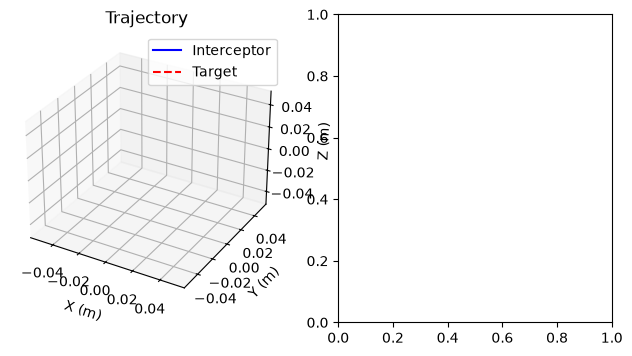

In [2]:
# Build preset optionsinterceptor_presets = get_interceptor_presets()target_presets = get_target_presets()interceptor_preset_dropdown = widgets.Dropdown(    options=list(interceptor_presets.keys()),    value="vandenberg",    description="Interceptor Preset:",)target_preset_dropdown = widgets.Dropdown(    options=list(target_presets.keys()),    value="ballistic_short_range",    description="Target Preset:",)interceptor_mass_slider = widgets.FloatSlider(    value=1000.0, min=100.0, max=5000.0, step=100.0,    description="Interceptor Mass (kg):",)kill_radius_slider = widgets.FloatSlider(    value=0.5, min=0.1, max=10.0, step=0.1,    description="Kill Radius (m):",)guidance_n_slider = widgets.FloatSlider(    value=4.0, min=1.0, max=10.0, step=0.5,    description="Guidance Gain N:",)n_trials_slider = widgets.IntSlider(    value=20, min=5, max=100, step=5,    description="MC Trials:",)# Geodetic custom inputscustom_lat = widgets.FloatText(value=34.7, description="Lat (deg):")custom_lon = widgets.FloatText(value=-120.6, description="Lon (deg):")custom_alt = widgets.FloatText(value=0.0, description="Alt (m):")custom_target_lat = widgets.FloatText(value=34.7, description="Tgt Lat (deg):")custom_target_lon = widgets.FloatText(value=-120.6, description="Tgt Lon (deg):")custom_target_alt = widgets.FloatText(value=0.0, description="Tgt Alt (m):")run_button = widgets.Button(    description="Run Engagement",    button_style="success",)status_label = widgets.Label(value="Ready")output_area = widgets.Output()def on_run_clicked(b):    status_label.value = "Running..."    with output_area:        clear_output(wait=True)        interceptor = InterceptorConfig(            name="Interactive",            mass=interceptor_mass_slider.value,            kill_radius=kill_radius_slider.value,        )        guidance_cfg = GuidanceConfig(            terminal_n=guidance_n_slider.value,            terminal_kill_radius=kill_radius_slider.value,        )        guidance = GuidanceLaw(config=guidance_cfg)                # Interceptor launch site        interceptor_name = interceptor_preset_dropdown.value        if interceptor_name == "custom_geodetic":            launch_site = set_interceptor_geodetic(                custom_lat.value, custom_lon.value, custom_alt.value            )        else:            launch_site = interceptor_preset(interceptor_name)                # Target preset        target_name = target_preset_dropdown.value        if target_name == "custom_geodetic":            preset = set_target_geodetic(                custom_target_lat.value,                custom_target_lon.value,                custom_target_alt.value,            )        else:            preset = target_preset(target_name)        target = preset.target        scenario = EngagementScenario(            interceptor_launch_site=launch_site,            **preset.engagement.__dict__,        )        print(f"Interceptor preset: {interceptor_name}")        print(f"Launch site (ECEF): {launch_site}")        print(f"Target preset: {target_name}")        if preset.description:            print(f"Description: {preset.description}")        print(f"Running {n_trials_slider.value} trials...")        result = run_engagement(interceptor, guidance, target, scenario, n_trials=n_trials_slider.value)        status_label.value = "Done"        print(f"Nominal miss: {result.miss_distance:.2f} m")        print(f"Kill: {result.kill_assessment}")        if result.monte_carlo:            print(f"MC kill probability: {result.monte_carlo.kill_probability:.2%}")            print(f"Mean miss: {result.monte_carlo.mean_miss:.2f} m")            print(f"Std miss: {result.monte_carlo.std_miss:.2f} m")        fig = plt.figure(figsize=(12, 4))        ax1 = fig.add_subplot(131, projection="3d")        result.plot_3d(ax=ax1)        ax1.set_title("Trajectory")        ax2 = fig.add_subplot(132)        result.plot_miss_distance_distribution(ax=ax2)        ax2.set_title("Miss Distance Distribution")        ax3 = fig.add_subplot(133)        if result.monte_carlo:            misses = result.monte_carlo.miss_distances            kill_radius = kill_radius_slider.value            kill_count = np.sum(np.array(misses) < kill_radius)            ax3.bar(["Miss < Kill Radius", "Miss > Kill Radius"],                     [kill_count, len(misses) - kill_count])            ax3.set_title("Kill / No-Kill Count")        plt.tight_layout()        plt.show()run_button.on_click(on_run_clicked)ui = widgets.VBox([    widgets.HBox([interceptor_preset_dropdown, target_preset_dropdown]),    widgets.HBox([custom_lat, custom_lon, custom_alt]),    widgets.HBox([custom_target_lat, custom_target_lon, custom_target_alt]),    widgets.HBox([interceptor_mass_slider, kill_radius_slider]),    widgets.HBox([guidance_n_slider, n_trials_slider]),    widgets.HBox([run_button, status_label]),    output_area,])display(ui)display(HTML("<p><i>Select presets above, then click <b>Run Engagement</b>.</i></p>"))